In [1]:
import gpflow
import matplotlib.pyplot as plt 
import scipy.stats as ss
import numpy as np 
from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atlikelihood import TransferLikelihood
from atkernel import TransferKernel

2025-10-14 17:25:42.186614: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 17:25:42.190436: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-14 17:25:42.255069: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-14 17:25:42.256744: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 17:25:43.055258: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

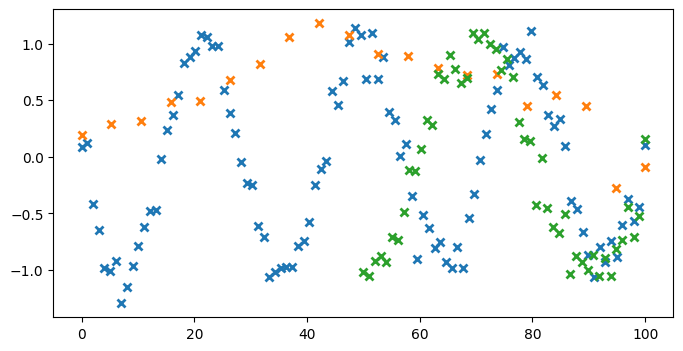

In [2]:
# make a dataset with two outputs, correlated, heavy-tail noise. One has more noise than the other.
X1 = np.linspace(0, 100, 100)[:,None]  # Observed locations for first output
X2 = np.linspace(0, 100, 20)[:,None]  # Observed locations for second output
Xtest = np.linspace(50, 100, 50)[:,None]
Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.15
Y2 = np.sin(6 * X2 + 0.1) + np.random.randn(*X2.shape) * 0.15
Ytest = np.sin(6 * Xtest+ 0.1) + np.random.randn(*Xtest.shape) * 0.15
plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, "x", mew=2)
plt.plot(X2, Y2, "x", mew=2)
plt.plot(Xtest, Ytest, "x", mew=2)



In [3]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

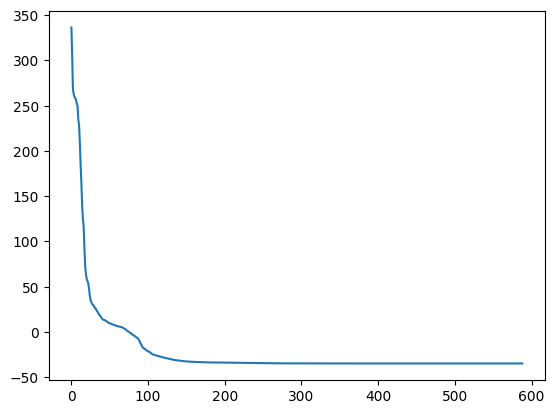

In [4]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

# This likelihood switches between Gaussian noise with different variances for each f_i:
lik = TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian())
# now build the GP model as normal
m = gpflow.models.VGP((X_augmented, Y_augmented), kernel=kern, likelihood=lik)

# fit the covariance function parameters
res = gpflow.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
plt.plot(res["loss_history"])

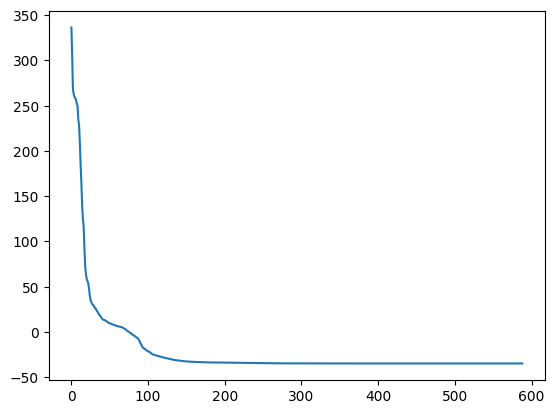

max lml at tf.Tensor(35.04305661708176, shape=(), dtype=float64)


NameError: name 'plot_coreg' is not defined

In [5]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

# This likelihood switches between Gaussian noise with different variances for each f_i:
lik = TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian())
# now build the GP model as normal

for k in [kern, kern2]:
    m = gpflow.models.VGP((X_augmented, Y_augmented), kernel=kern, likelihood=lik)

    # fit the covariance function parameters
    res = gpflow.optimizers.Scipy().minimize(
        m.training_loss,
        m.trainable_variables,
        method="L-BFGS-B",
        track_loss_history=True
    )
    plt.plot(res["loss_history"])
    plt.show()
    print("max lml at", m.maximum_log_likelihood_objective())
    plot_coreg(m)
    plt.show()

In [ ]:
m

name,class,transform,prior,trainable,shape,dtype,value
VGP.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.06036473525360705
VGP.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,8.71714
VGP.kernel.kernels[1].W,Parameter,Identity,,True,"(2, 1)",float64,[[4.50082 ] [0.82099904]]
VGP.kernel.kernels[1].kappa,Parameter,Softplus,,True,"(2,)",float64,[0.13899657 1.53876 ]
VGP.likelihood.source.variance VGP.likelihood.likelihoods[0].variance,Parameter,Softplus + Shift,,True,(),float64,0.02581564546286314
VGP.likelihood.target.variance VGP.likelihood.likelihoods[1].variance,Parameter,Softplus + Shift,,True,(),float64,0.017337055347959623
VGP.num_data,Parameter,Identity,,False,(),int32,120
VGP.q_mu,Parameter,Identity,,True,"(120, 2)",float64,"[[-1.56863369e-01, -1.56863369e-01..."
VGP.q_sqrt,Parameter,FillTriangular,,True,"(2, 120, 120)",float64,"[[[1.01361261e-01, 0.00000000e+00, 0.00000000e+00..."


(20, 1) (20,)


/tmp/ipykernel_2974/3312395202.py:22: RuntimeWarning: invalid value encountered in sqrt
  (cond_mu - 2 * np.sqrt(var))[:, 0],
/tmp/ipykernel_2974/3312395202.py:23: RuntimeWarning: invalid value encountered in sqrt
  (cond_mu + 2 * np.sqrt(var))[:, 0],


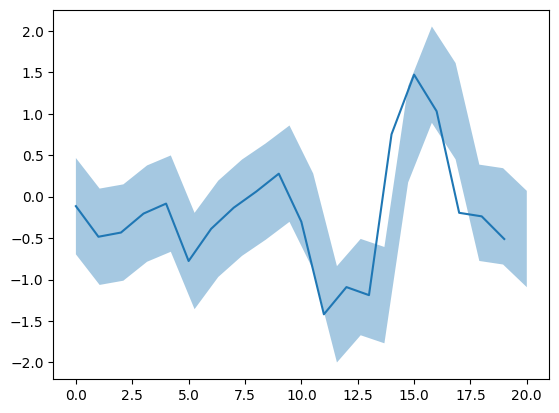

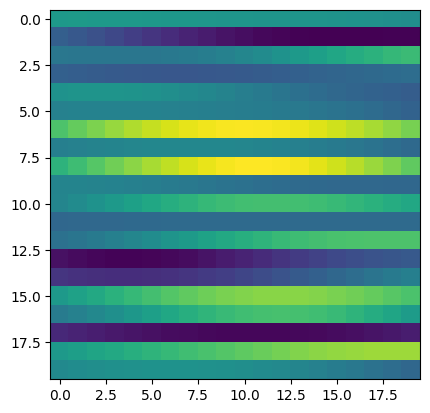

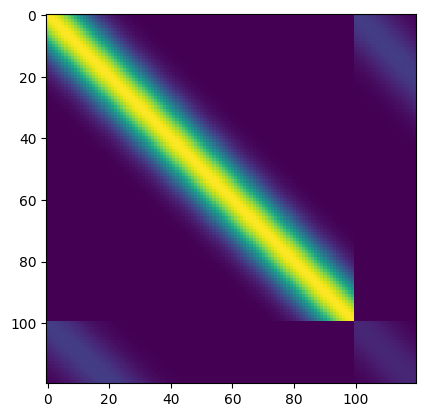

In [ ]:
import tensorflow as tf
# K21 K11 f and K22 - K21 K11 K12 
def conditional_coregion(model):
    kernel = model.kernel(X_augmented)
    K11 = kernel[:len(X1), :len(X1)]
    K11_inv = tf.linalg.inv(K11)
    K22 = kernel[len(X1):, len(X1):]
    K21 = kernel[len(X1):, :len(X1)]
    K12 = tf.transpose(K21)
    Ks = tf.matmul(K21, K11_inv)
    cond_mu  = tf.matmul(Ks, Y1)
    cond_var = K22 - tf.matmul(Ks, K12)
    return cond_mu, cond_var

cond_mu, cond_var = conditional_coregion(m)
var = tf.linalg.diag_part(cond_var) 
print(cond_mu.shape, var.shape)
plt.plot(tf.reshape(cond_mu, (-1, 1)))

plt.fill_between(
    X2[:, 0],
    (cond_mu - 2 * np.sqrt(var))[:, 0],
    (cond_mu + 2 * np.sqrt(var))[:, 0],
    alpha=0.4,
)
plt.show()
plt.imshow(cond_var)
plt.show()
plt.imshow(m.kernel(X_augmented))

In [6]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot_coreg(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()

def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(Xtest)
    (line,) = plt.plot(X2, Y2, "x", mew=2)
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()


In [7]:
at_gpr = AdaptiveTransferGPR(data_source=(X1, Y1), data_target=(X2, Y2), base_kernel=gpflow.kernels.RBF())
at_gpr

TypeError: AdaptiveTransferGPR.__init__() got an unexpected keyword argument 'base_kernel'

In [8]:
print("Training loss value before training:", at_gpr.training_loss().numpy())
opt = gpflow.optimizers.Scipy()
res = opt.minimize(at_gpr.training_loss, at_gpr.trainable_variables, track_loss_history=True)

gpflow.utilities.print_summary(at_gpr)
print("Training loss value after training:", at_gpr.training_loss().numpy())
at_gpr.training_loss
at_gpr.trainable_variables
at_gpr

plt.plot(res["loss_history"])
plt.show()

NameError: name 'at_gpr' is not defined

In [9]:
plot(at_gpr)
plot_coreg(m)
plt.show()
plt.imshow(at_gpr.kernel(np.vstack((X1, X2))))
plt.show()
coreg.output_covariance().numpy()

NameError: name 'at_gpr' is not defined

2025-10-14 17:22:01.183085: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-10-14 17:22:01.268912: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-10-14 17:22:01.338348: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-10-14 17:22:01.402584: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-10-14 17:22:01.464192: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

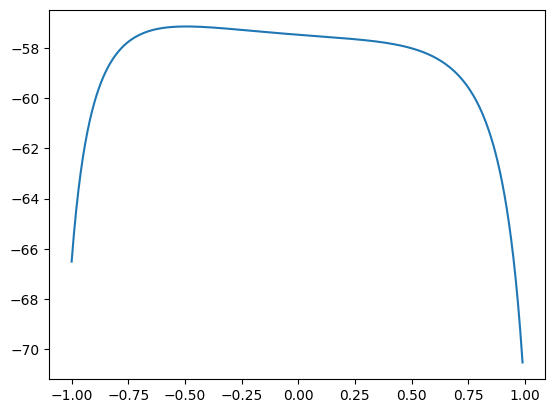

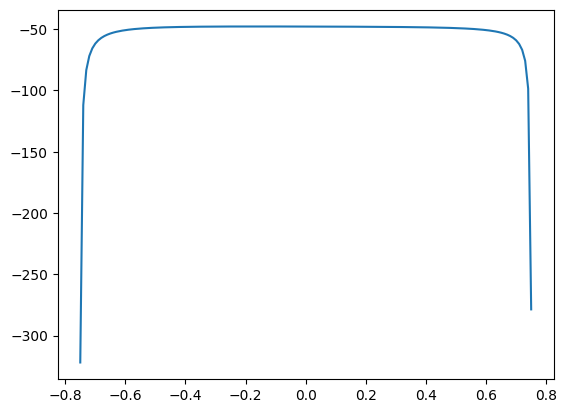

In [43]:
lambdas = np.arange(-0.9999, 0.9999, 0.01)
lmls = np.zeros((len(lambdas), 2))
for i, l in enumerate(lambdas):
    at_gpr = AdaptiveTransferGPR(data_source=(X1, Y1), data_target=(X2, Y2), base_kernel=gpflow.kernels.RBF(), lmb=l)
    m = ConditionalMOGP((X_augmented, Y_augmented), kernel=TransferKernel(lmb=l, kernel=gpflow.kernels.RBF(), source_length=len(X1)), likelihood=lik)
    lmls[i, 0] = at_gpr.maximum_log_likelihood_objective()
    lmls[i, 1] = m.maximum_log_likelihood_objective()

plt.plot(lambdas, lmls[:,0])
plt.show()
plt.plot(lambdas, lmls[:,1])
plt.show()


## Compare variance estimates

In [ ]:
gpr = gpflow.models.GPR((np.vstack((X1, X2)), np.vstack((Y1, Y2))), kernel=gpflow.kernels.RBF())

In [ ]:
opt = gpflow.optimizers.Scipy()
opt.minimize(gpr.training_loss, gpr.trainable_variables)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 132.34558029442508
        x: [ 6.590e+00 -8.360e-01 -1.157e+00]
      nit: 15
      jac: [ 2.050e-05 -1.943e-05 -1.483e-04]
     nfev: 18
     njev: 18
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,0.360075
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,6.59178
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.273285


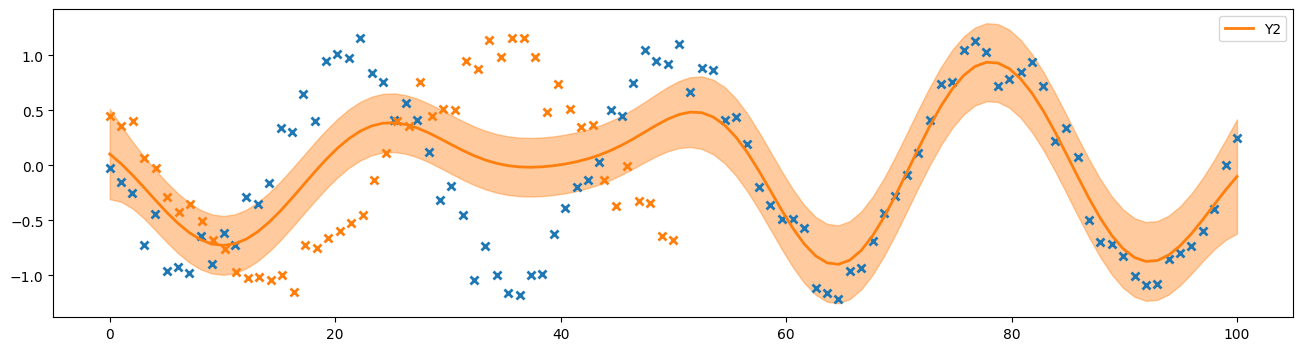

In [ ]:
plot(gpr)
gpr

In [ ]:
for mod in (gpr, at_gpr, m):
    print(mod.maximum_log_likelihood_objective())

print(m.maximum_log_likelihood_objective() - at_gpr.maximum_log_likelihood_objective())

tf.Tensor(-132.34558029442508, shape=(), dtype=float64)
tf.Tensor(-1599807.4862996493, shape=(), dtype=float64)
tf.Tensor(48.40234898466437, shape=(), dtype=float64)
tf.Tensor(1599855.888648634, shape=(), dtype=float64)


In [ ]:
from sklearn.metrics import mean_squared_error
m_pred, var_pred = at_gpr.predict_f(Xtest)
coreg_pred, _ = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
print(coreg_pred.shape, m_pred.shape, Ytest.shape)

print(mean_squared_error(m_pred, Ytest))
print(mean_squared_error(coreg_pred, Ytest))


(50, 2) (50, 1) (50, 1)
5.37828197556581


ValueError: y_true and y_pred have different number of output (2!=1)